In [38]:
df = pd.read_csv('/content/loan_data.csv')

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

Epoch 1/100
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8465 - loss: 0.3349 - val_accuracy: 0.8858 - val_loss: 0.2362
Epoch 2/100
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8866 - loss: 0.2407 - val_accuracy: 0.8944 - val_loss: 0.2235
Epoch 3/100
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8930 - loss: 0.2305 - val_accuracy: 0.9006 - val_loss: 0.2198
Epoch 4/100
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8970 - loss: 0.2238 - val_accuracy: 0.9017 - val_loss: 0.2159
Epoch 5/100
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9020 - loss: 0.2177 - val_accuracy: 0.9008 - val_loss: 0.2144
Epoch 6/100
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9007 - loss: 0.2145 - val_accuracy: 0.9025 - val_loss: 0.2093
Epoch 7/100
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9059 - loss: 0.2104 - val_accuracy: 0.9064 - val_loss: 0.2060
Epoch 8/100
1013/1013 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9048 - loss: 0

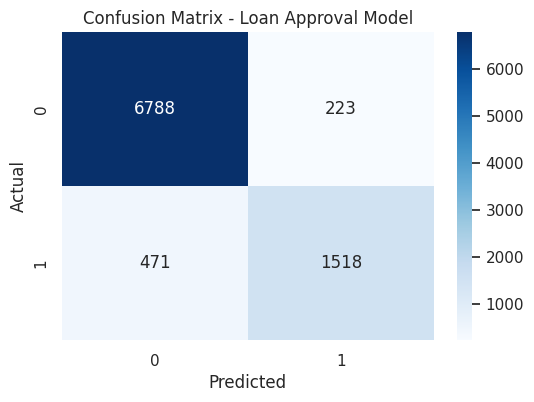

In [41]:

# One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define Features (X) and Target (y)
X = df_encoded.drop('loan_status', axis=1).values
y = df_encoded['loan_status'].values

# Splitting and Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Building ANN
classifier = Sequential()

# Input layer
classifier.add(Dense(units=16, activation='relu', input_dim=X_train.shape[1]))
classifier.add(Dropout(0.2))

# Second Hidden layer
classifier.add(Dense(units=8, activation='relu'))

# Output layer
classifier.add(Dense(units=1, activation='sigmoid'))

# Compiling and Fitting with Early Stopping
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5)

classifier.fit(X_train, y_train,
               validation_split=0.1,
               batch_size=32,
               epochs=100,
               callbacks=[early_stop])

# EVALUATION

#  predictions
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Loan Approval Model')
plt.show()